In [14]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.3 MB/s eta 0:00:08
   -- ------------------------------------- 0.5/9.6 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.6 MB 856.5 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.6 MB 807.0 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.6 MB 971.1 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.6 MB 1.0 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.6 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.6 MB 1.2 MB/s eta 0:00:07
   ------------ --------------------------- 2.9/9.6 MB 1.2 MB/s eta 0:00:06
   ------------- -------------------------- 3.1/9.6 MB 1.2 MB/s eta 0:00:06
   -------------- ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits import mplot3d

In [3]:
df = pd.read_excel('Produksi Padi di Provinsi Jawa Timur 2025.xlsx')
df

,Kabupaten/Kota,Luas Panen Tanaman Padi (ha) (Ha),Produktivitas Tanaman Padi (ku/ha) (Ku/ha),Rekap Produksi Padi (ton) (Ton)
0,Pacitan,26774,49.49,132516
1,Ponorogo,74200,58.80,436300
2,Trenggalek,27943,56.55,158029
3,Tulungagung,39342,61.15,240566
4,Blitar,35796,64.65,231437
5,Kediri,34198,57.99,198324
6,Malang,38178,64.53,246370
7,Lumajang,50052,55.92,279902
8,Jember,135436,50.17,679514
9,Banyuwangi,75650,59.97,453636


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Kabupaten/Kota                              38 non-null     str    
 1   Luas Panen Tanaman Padi (ha) (Ha)           38 non-null     int64  
 2   Produktivitas Tanaman Padi (ku/ha) (Ku/ha)  38 non-null     float64
 3   Rekap Produksi Padi (ton) (Ton)             38 non-null     int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 1.3 KB


In [5]:
X = df[['Luas Panen Tanaman Padi (ha) (Ha)', 'Produktivitas Tanaman Padi (ku/ha) (Ku/ha)']]
X.head()

,Luas Panen Tanaman Padi (ha) (Ha),Produktivitas Tanaman Padi (ku/ha) (Ku/ha)
0,26774,49.49
1,74200,58.80
2,27943,56.55
3,39342,61.15
4,35796,64.65


In [6]:
y = df['Rekap Produksi Padi (ton) (Ton)']
y.head()

0    132516
1    436300
2    158029
3    240566
4    231437
Name: Rekap Produksi Padi (ton) (Ton), dtype: int64

[INFO] Menampilkan grafik scatter plot 3D... Silakan tutup jendela grafik untuk melanjutkan proses perhitungan regresi.


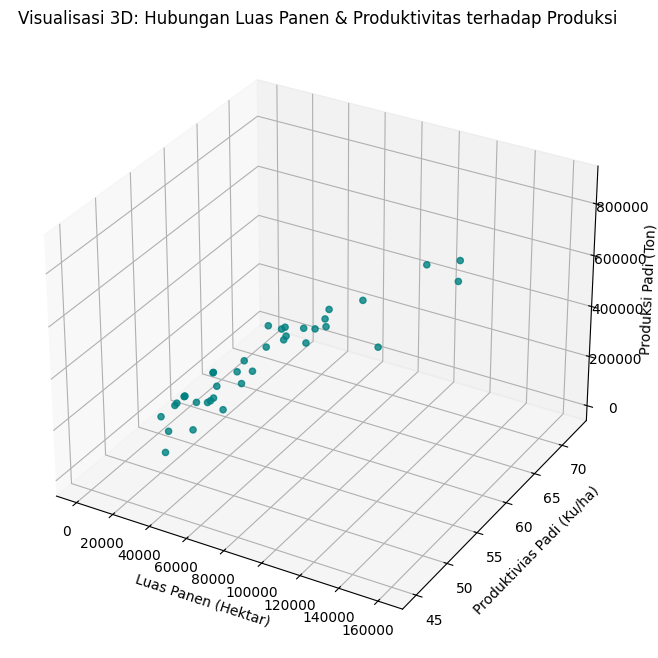

--------------------------------------------------


In [8]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

x1 = df['Luas Panen Tanaman Padi (ha) (Ha)']
x2 = df['Produktivitas Tanaman Padi (ku/ha) (Ku/ha)']

# Membuat scatter plot 3D
ax.scatter3D(x1, x2, y, color='teal', marker='o', alpha=0.8)

# Memberikan label pada sumbu grafik
ax.set_title('Visualisasi 3D: Hubungan Luas Panen & Produktivitas terhadap Produksi')
ax.set_xlabel('Luas Panen (Hektar)')
ax.set_ylabel('Produktivias Padi (Ku/ha)')
ax.set_zlabel('Produksi Padi (Ton)')

print("[INFO] Menampilkan grafik scatter plot 3D... Silakan tutup jendela grafik untuk melanjutkan proses perhitungan regresi.")
plt.show()
print("-" * 50)

In [9]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

koef_luas_panen = regr.coef_[0]
koef_produktivitas = regr.coef_[1]
konstanta = regr.intercept_

print("=== HASIL ANALISIS REGRESI BERGANDA ===")
print(f"Koefisien Luas Panen (b1) : {koef_luas_panen:.6f}")
print(f"Koefisien Produktivitas (b2): {koef_produktivitas:.6f}")
print(f"Konstanta (a)             : {konstanta:.6f}")
print("\nPersamaan Matematika yang Terbentuk:")
print(f"y = {konstanta:.4f} + ({koef_luas_panen:.4f} * Luas Panen) + ({koef_produktivitas:.4f} * Produktivitas)")
print("-" * 50)

=== HASIL ANALISIS REGRESI BERGANDA ===
Koefisien Luas Panen (b1) : 5.716021
Koefisien Produktivitas (b2): 3646.378485
Konstanta (a)             : -212065.276863

Persamaan Matematika yang Terbentuk:
y = -212065.2769 + (5.7160 * Luas Panen) + (3646.3785 * Produktivitas)
--------------------------------------------------


In [10]:
def hitung_prediksi_rumus(luas, produktivitas):
    prediksi = konstanta + (koef_luas_panen * luas) + (koef_produktivitas * produktivitas)
    return prediksi

In [13]:
luas_baru = 513
produktiv_baru = 58.99

produksi_via_rumus = hitung_prediksi_rumus(luas_baru, produktiv_baru)

print("=== CONTOH SIMULASI PREDIKSI DATA BARU ===")
print(f"Input Luas Panen             : {luas_baru:,} Hektar")
print(f"Input Produktivitas          : {produktiv_baru:,} ku/ha")
print("-" * 50)
print(f"Hasil Prediksi (Rumus Manual): {produksi_via_rumus:,.2f} Ton")
print("=========================================================")

=== CONTOH SIMULASI PREDIKSI DATA BARU ===
Input Luas Panen             : 513 Hektar
Input Produktivitas          : 58.99 ku/ha
--------------------------------------------------
Hasil Prediksi (Rumus Manual): 5,966.91 Ton
